# EXPT NO. 6: IMPLEMENTATION OF LONG SHORT-TERM MEMORY (LSTM) FOR SENTIMENT ANALYSIS

**Student Name:** Mohamed Aashik S  
**Roll Number:** 24BAD072  

## Part A: Dataset Preparation


In [10]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
VOCAB_SIZE = 10000       # Keep the 10,000 most frequent words
MAX_LEN = 200            # Maximum number of tokens in each review
PAD_VALUE = 0

(x_train_full, y_train_full), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print("Training samples:", len(x_train_full))
print("Test samples:", len(x_test))
print("Example training label:", int(y_train_full[0]))
print("Example sequence (first 20 tokens):", x_train_full[0][:20])
print("Example sequence length:", len(x_train_full[0]))
print("Label meaning: 0 = Negative, 1 = Positive")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Test samples: 25000
Example training label: 1
Example sequence (first 20 tokens): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Example sequence length: 218
Label meaning: 0 = Negative, 1 = Positive


Training label distribution:


,Number of reviews
Positive,12500
Negative,12500


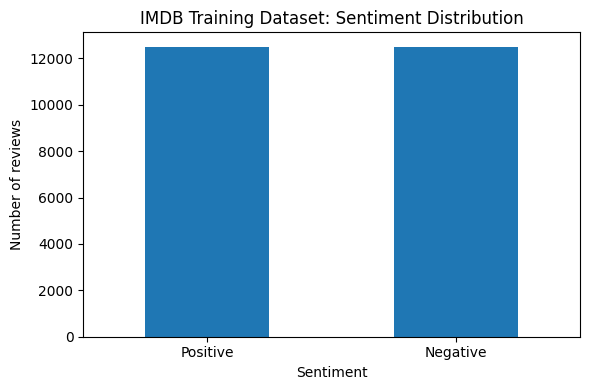

In [3]:
label_counts = pd.Series(y_train_full).map({0: "Negative", 1: "Positive"}).value_counts()
print("Training label distribution:")
display(label_counts.to_frame(name="Number of reviews"))

plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar")
plt.title("IMDB Training Dataset: Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:

word_index = imdb.get_word_index()
index_word = {index + 3: word for word, index in word_index.items()}
index_word[0] = "<PAD>"
index_word[1] = "<START>"
index_word[2] = "<UNK>"
index_word[3] = "<UNUSED>"

def decode_review(sequence):
    return " ".join(index_word.get(int(token), "<UNK>") for token in sequence)

for i in range(3):
    print(f"Review {i + 1} | Sentiment: {'Positive' if y_train_full[i] == 1 else 'Negative'}")
    print(decode_review(x_train_full[i][:100]))
    print("-" * 80)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Review 1 | Sentiment: Positive
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was
--------------------------------------------------------------------------------
Review 2 | Sentiment: Negative
<START> big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the worst ever made the plot is paper thin and ridiculo

In [5]:

x_train = x_train_full[5000:]
y_train = y_train_full[5000:]
x_val = x_train_full[:5000]
y_val = y_train_full[:5000]

x_train_pad = pad_sequences(x_train, maxlen=MAX_LEN, padding="post", truncating="post", value=PAD_VALUE)
x_val_pad = pad_sequences(x_val, maxlen=MAX_LEN, padding="post", truncating="post", value=PAD_VALUE)
x_test_pad = pad_sequences(x_test, maxlen=MAX_LEN, padding="post", truncating="post", value=PAD_VALUE)

print("Training input shape:", x_train_pad.shape)
print("Validation input shape:", x_val_pad.shape)
print("Test input shape:", x_test_pad.shape)
print("Training labels shape:", y_train.shape)
print("Validation labels shape:", y_val.shape)
print("Test labels shape:", y_test.shape)

Training input shape: (20000, 200)
Validation input shape: (5000, 200)
Test input shape: (25000, 200)
Training labels shape: (20000,)
Validation labels shape: (5000,)
Test labels shape: (25000,)


## Part B: Implementing the LSTM Model



In [3]:
from tensorflow.keras import layers, models
import tensorflow as tf

VOCAB_SIZE = 10000
MAX_LEN = 200
EMBEDDING_DIM = 128

model = models.Sequential([
    layers.Input(shape=(MAX_LEN,), name="review_tokens"),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, mask_zero=True, name="word_embedding"),
    layers.SpatialDropout1D(0.2, name="dropout_layer"),
    layers.Bidirectional(layers.LSTM(64, return_sequences=False, name="lstm_layer")),
    layers.Dense(64, activation="relu", name="dense_layer"),
    layers.Dropout(0.5, name="dense_dropout"),
    layers.Dense(1, activation="sigmoid", name="sentiment_output")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ word_embedding (Embedding)      │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer                   │ (None, 200, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer (Dense)             │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_dropout (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentiment_output (Dense)        │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,137 (5.29 MB)

 Trainable params: 1,387,137 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

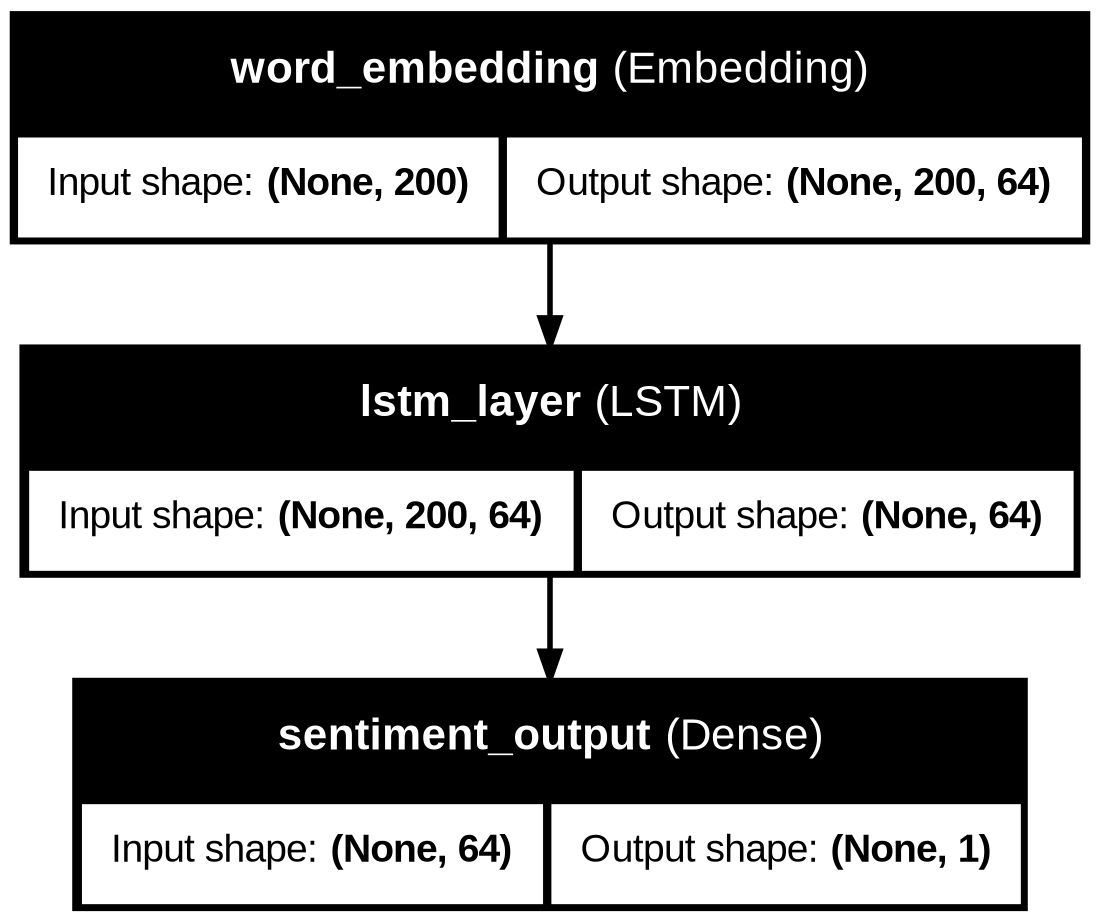

In [7]:
try:
    tf.keras.utils.plot_model(
        model,
        to_file="lstm_model_architecture.png",
        show_shapes=True,
        show_layer_names=True
    )
    from IPython.display import Image, display
    display(Image(filename="lstm_model_architecture.png"))
except Exception as error:
    print("Architecture image could not be generated in this environment.")
    print("The model summary above displays the architecture instead.")
    print("Details:", error)

## Part C: Model Training and Performance Evaluation


In [6]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb

# Ensure dataset is loaded and padded if the variables were cleared
try:
    _ = x_train_pad
except NameError:
    PAD_VALUE = 0
    VOCAB_SIZE = 10000
    MAX_LEN = 200
    (x_train_full, y_train_full), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)
    x_train = x_train_full[5000:]
    y_train = y_train_full[5000:]
    x_val = x_train_full[:5000]
    y_val = y_train_full[:5000]
    x_train_pad = pad_sequences(x_train, maxlen=MAX_LEN, padding="post", truncating="post", value=PAD_VALUE)
    x_val_pad = pad_sequences(x_val, maxlen=MAX_LEN, padding="post", truncating="post", value=PAD_VALUE)
    x_test_pad = pad_sequences(x_test, maxlen=MAX_LEN, padding="post", truncating="post", value=PAD_VALUE)

EPOCHS = 5
BATCH_SIZE = 128

history = model.fit(
    x_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val_pad, y_val),
    verbose=1
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.7541 - loss: 0.4856 - val_accuracy: 0.8544 - val_loss: 0.3540
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8979 - loss: 0.2625 - val_accuracy: 0.8610 - val_loss: 0.3284
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9309 - loss: 0.1900 - val_accuracy: 0.8546 - val_loss: 0.4303
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9493 - loss: 0.1408 - val_accuracy: 0.8608 - val_loss: 0.4400
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9689 - loss: 0.0915 - val_accuracy: 0.8494 - val_loss: 0.4788


In [8]:
import pandas as pd
import numpy as np

history_df = pd.DataFrame(history.history)
history_df.index = np.arange(1, len(history_df) + 1)
history_df.index.name = "Epoch"

print("Training history:")
display(history_df)

final_training_accuracy = history.history["accuracy"][-1]
final_validation_accuracy = history.history["val_accuracy"][-1]
final_training_loss = history.history["loss"][-1]
final_validation_loss = history.history["val_loss"][-1]

print(f"Final training accuracy:   {final_training_accuracy:.4f}")
print(f"Final validation accuracy: {final_validation_accuracy:.4f}")
print(f"Final training loss:       {final_training_loss:.4f}")
print(f"Final validation loss:     {final_validation_loss:.4f}")

Training history:


,accuracy,loss,val_accuracy,val_loss
Epoch,,,,
1,0.75405,0.485618,0.8544,0.354001
2,0.89790,0.262520,0.8610,0.328379
3,0.93090,0.190048,0.8546,0.430256
4,0.94935,0.140753,0.8608,0.440030
5,0.96895,0.091457,0.8494,0.478843


Final training accuracy:   0.9689
Final validation accuracy: 0.8494
Final training loss:       0.0915
Final validation loss:     0.4788


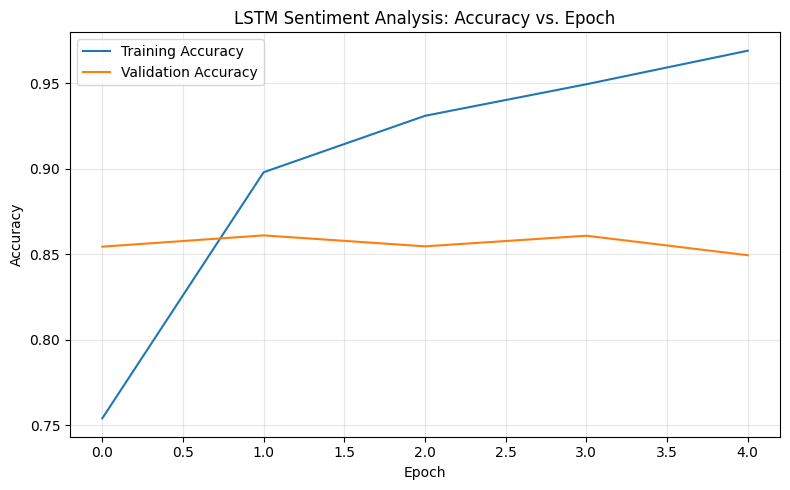

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Sentiment Analysis: Accuracy vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

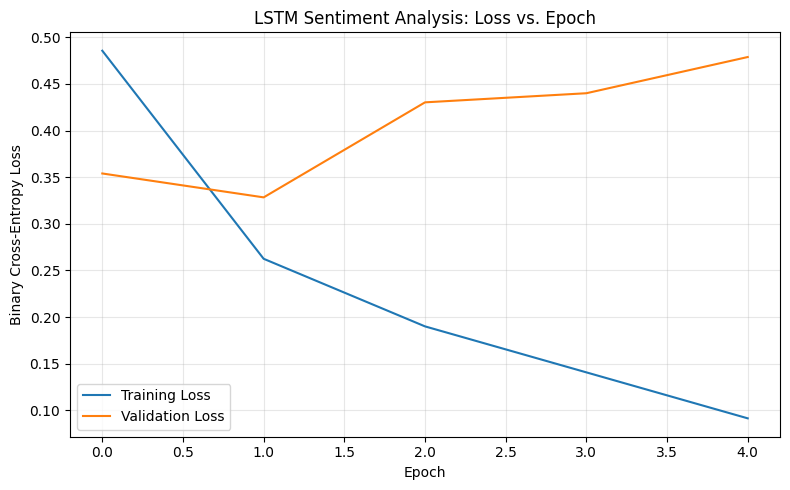

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Sentiment Analysis: Loss vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
test_loss, test_accuracy = model.evaluate(x_test_pad, y_test, verbose=0)
test_probabilities = model.predict(x_test_pad, batch_size=BATCH_SIZE, verbose=0).ravel()
y_pred = (test_probabilities >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

metrics_df = pd.DataFrame({
    "Metric": ["Test Loss", "Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [test_loss, accuracy, precision, recall, f1]
})

print("Test dataset evaluation:")
display(metrics_df)
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"], zero_division=0))

Test dataset evaluation:


,Metric,Value
0,Test Loss,0.546662
1,Accuracy,0.828960
2,Precision,0.859441
3,Recall,0.786560
4,F1-score,0.821387



Classification report:
              precision    recall  f1-score   support

    Negative       0.80      0.87      0.84     12500
    Positive       0.86      0.79      0.82     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



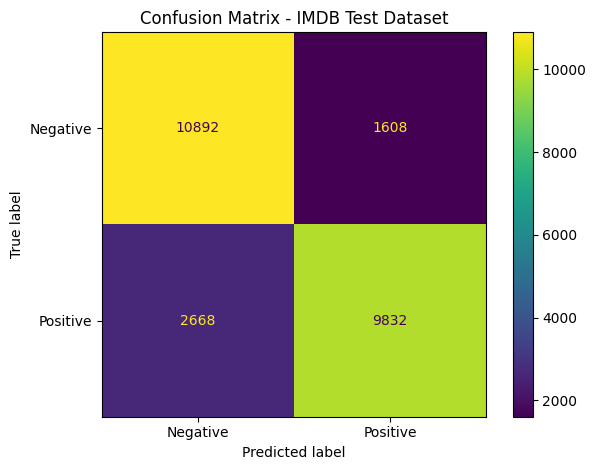

Confusion matrix layout:
[[True Negative, False Positive],
 [False Negative, True Positive]]
[[10892  1608]
 [ 2668  9832]]


In [14]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
display_obj = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
display_obj.plot(values_format="d")
plt.title("Confusion Matrix - IMDB Test Dataset")
plt.tight_layout()
plt.show()

print("Confusion matrix layout:")
print("[[True Negative, False Positive],")
print(" [False Negative, True Positive]]")
print(cm)

## Part D: Sentiment Prediction and Experiment Management


In [16]:
import re
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb

# Ensure word_index is available
try:
    _ = word_index
except NameError:
    word_index = imdb.get_word_index()

UNKNOWN_TOKEN = 2
START_TOKEN = 1

def preprocess_new_review(text, max_len=MAX_LEN):
    words = re.findall(r"[a-zA-Z]+|[^\s\w]", text.lower())
    sequence = [START_TOKEN]
    for word in words:
        if word in word_index:
            token_id = word_index[word] + 3
            if token_id >= VOCAB_SIZE:
                token_id = UNKNOWN_TOKEN
        else:
            token_id = UNKNOWN_TOKEN
        sequence.append(token_id)
    return pad_sequences(
        [sequence],
        maxlen=max_len,
        padding="post",
        truncating="post",
        value=PAD_VALUE
    )

def predict_sentiment(review_text):
    prepared = preprocess_new_review(review_text)
    probability = float(model.predict(prepared, verbose=0)[0][0])
    sentiment = "Positive" if probability >= 0.5 else "Negative"
    return sentiment, probability

review_samples = [
    {
        "Review": "This movie was wonderful, exciting, and beautifully acted.",
        "Expected sentiment": "Positive"
    },
    {
        "Review": "The film was boring, confusing, and a complete waste of time.",
        "Expected sentiment": "Negative"
    },
    {
        "Review": "I enjoyed the story and would happily watch it again.",
        "Expected sentiment": "Positive"
    },
    {
        "Review": "The acting was poor and the story was disappointing.",
        "Expected sentiment": "Negative"
    }
]

prediction_rows = []
for sample in review_samples:
    predicted, probability = predict_sentiment(sample["Review"])
    prediction_rows.append({
        "Review": sample["Review"],
        "Expected sentiment": sample["Expected sentiment"],
        "Predicted sentiment": predicted,
        "Positive probability": round(probability, 4),
        "Match": predicted == sample["Expected sentiment"]
    })

prediction_df = pd.DataFrame(prediction_rows)
display(prediction_df)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


,Review,Expected sentiment,Predicted sentiment,Positive probability,Match
0,"This movie was wonderful, exciting, and beauti...",Positive,Positive,0.9951,True
1,"The film was boring, confusing, and a complete...",Negative,Negative,0.0002,True
2,I enjoyed the story and would happily watch it...,Positive,Positive,0.9839,True
3,The acting was poor and the story was disappoi...,Negative,Negative,0.0004,True


In [17]:
custom_review = "The movie was entertaining and the performances were excellent."
custom_sentiment, custom_probability = predict_sentiment(custom_review)

print("Custom review:", custom_review)
print("Predicted sentiment:", custom_sentiment)
print(f"Positive sentiment probability: {custom_probability:.4f}")

Custom review: The movie was entertaining and the performances were excellent.
Predicted sentiment: Positive
Positive sentiment probability: 0.9961
